## Importing Libraries

In [70]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import nltk 
nltk.download('wordnet')
nltk.download('punkt_tab')
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\senas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\senas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Loading Dataset

First we load the dataset that we preprocessed.

In [63]:
df = pd.read_csv('./../data/processed/20newsgroup_preprocessed_own.csv', on_bad_lines='skip', delimiter=";")
print(df.shape)
df.head()

(18828, 3)


,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism resources alt atheism arc...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism introduction alt atheism ...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,article charley wingate writes well john quite...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,kings become philosophers philosophers become ...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,article ida org ida org bob mcgwier writes how...


Next we need to remove rows without a value in the 'text_cleaned' column as that is what we will use.

In [64]:
df = df.dropna(subset=['text_cleaned'])
print(df.shape)

(18792, 3)


## Lemmatization (optional)

In this step we lemmatize all of our words to further preprocess it. This step should be omitted for this model as it only worsens the results.

In [53]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = nltk.word_tokenize(text)
    lemmas = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(lemmas)

df['text_cleaned'] = df['text_cleaned'].apply(lambda x: lemmatize_text(x))
df.head()

,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism resource alt atheism arch...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism introduction alt atheism ...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,article charley wingate writes well john quite...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,king become philosopher philosopher become kin...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,article ida org ida org bob mcgwier writes how...


## Encoding labels

This step might not be necessary for all models, but it is good to encode the target labels into numbers instead of using strings.

In [65]:
# Create and fit the encoder on the original target column
label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['target'])

# Print to verify
print("Unique labels in df (encoded):", np.unique(df['target']))
print("Label classes:", label_encoder.classes_)
df.head()

Unique labels in df (encoded): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Label classes: ['alt.atheism' 'comp.graphics' 'comp.os.ms-windows.misc'
 'comp.sys.ibm.pc.hardware' 'comp.sys.mac.hardware' 'comp.windows.x'
 'misc.forsale' 'rec.autos' 'rec.motorcycles' 'rec.sport.baseball'
 'rec.sport.hockey' 'sci.crypt' 'sci.electronics' 'sci.med' 'sci.space'
 'soc.religion.christian' 'talk.politics.guns' 'talk.politics.mideast'
 'talk.politics.misc' 'talk.religion.misc']


,target,text,text_cleaned
0,0,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism resources alt atheism arc...
1,0,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism introduction alt atheism ...
2,0,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,article charley wingate writes well john quite...
3,0,From: mathew <mathew@mantis.co.uk>\nSubject: R...,kings become philosophers philosophers become ...
4,0,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,article ida org ida org bob mcgwier writes how...


## Split the dataset

Before any further modifications we need to split the dataset into train and test subsets so that test values would remain unchanged. it is also important to split the dataset ina way that the training and test sets have the same label distribution.

In [66]:
X_train, X_test, y_train, y_test = train_test_split(df['text_cleaned'], df['target'], test_size=0.2, stratify=df['target'], random_state=42)

## Check distribution of labels

Next we check with a barplot if the distributions are indeed the same between subsets.

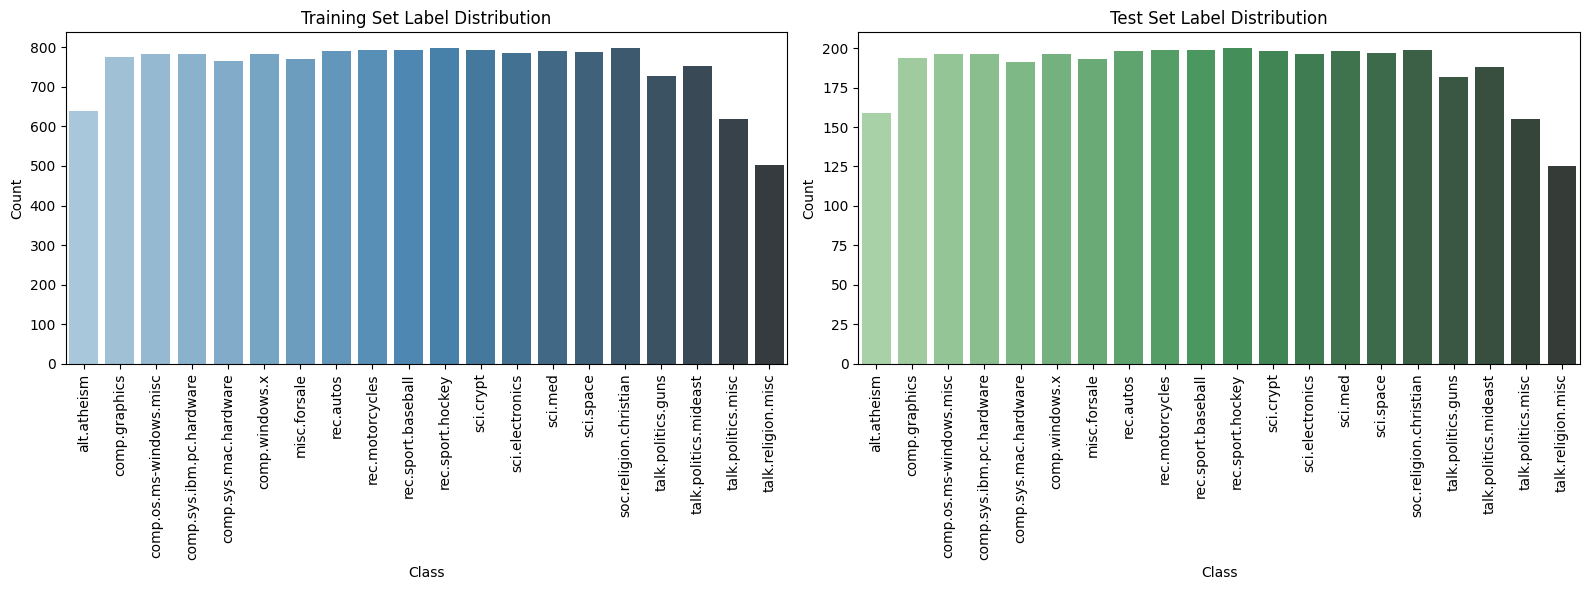

In [67]:
def plot_label_distribution(y_train, y_test, class_names):
    train_counts = pd.Series(y_train).value_counts().sort_index()
    test_counts = pd.Series(y_test).value_counts().sort_index()

    train_df = pd.DataFrame({'Class': class_names, 'Count': train_counts.values})
    test_df = pd.DataFrame({'Class': class_names, 'Count': test_counts.values})

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(data=train_df, x='Class', y='Count', hue='Class', palette="Blues_d", legend=False, ax=axs[0])
    axs[0].set_title('Training Set Label Distribution')
    axs[0].set_ylabel('Count')
    axs[0].set_xlabel('Class')
    axs[0].tick_params(axis='x', rotation=90)

    sns.barplot(data=test_df, x='Class', y='Count', hue='Class', palette="Greens_d", legend=False, ax=axs[1])
    axs[1].set_title('Test Set Label Distribution')
    axs[1].set_ylabel('Count')
    axs[1].set_xlabel('Class')
    axs[1].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()

plot_label_distribution(y_train, y_test, class_names=label_encoder.classes_)

As they are the same we can move onto the next step.

## Chunk the documents

As some documents are longer than others we split them. This will give us more examples as the dataset is relatively small, as well as help the vectorizer better generalize the representations.

We use a chunk size of 150 words with an overlap of 25 words.

In [68]:
def chunk_text(text, chunk_size=50, overlap=15):
    words = text.split()
    if len(words) < chunk_size:
        return [' '.join(words)]  # Keep short texts as a single chunk
    return [' '.join(words[i:i+chunk_size])
            for i in range(0, len(words) - chunk_size + 1, chunk_size - overlap)]

# New lists to store chunked data
X_train_chunked = []
y_train_chunked = []

# Apply chunking
for text, label in zip(X_train, y_train):
    chunks = chunk_text(text, chunk_size=150, overlap=25)
    X_train_chunked.extend(chunks)
    y_train_chunked.extend([label] * len(chunks))

print(f"Original X_train size: {len(X_train)}")
print(f"Chunked X_train size: {len(X_train_chunked)}")

Original X_train size: 15033
Chunked X_train size: 19558


We gained about 4000 new examples this also shows that only a third at most, of the dataset contained longer texts than 150 words.

## Tokenizing the documents

Next we train a Tf-idf vectorizer to get a representation containing 50000 of the best features in the dataset. Using an ngram range of 1-3 means we can have two or three words that follow each other as a feature giving some semantic value to them.

In [73]:
# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=50000, stop_words="english", ngram_range = (1,3))

# Transform text data into TF-IDF features
X_tfidf = vectorizer.fit_transform(X_train_chunked)

# Show shape of transformed data
print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (19558, 50000)


Next we preview the vectorized documents by showing the first 20 

In [74]:
print(vectorizer.get_feature_names_out()[:20])

['aab' 'aachen' 'aamir' 'aamir qazi' 'aamir qazi care' 'aan' 'aap' 'aaron'
 'aaron bryce' 'aaron bryce cardenas' 'aaron ray' 'aaron ray clements'
 'aas' 'abandon' 'abandoned' 'abandoning' 'abate' 'abbott' 'abbreviation'
 'abbreviations']


## Tokenize test data

Next we tokenize the test dataset with the vectorizer trained on the train dataset.

In [75]:
# Vectorize the test data using the same vectorizer
X_test_tfidf = vectorizer.transform(X_test)

## Training the model

For the first model we chose a Naive Bayes classifier as it is simple and effective.

In [76]:
# Initialize and train the model
nb_classifier = MultinomialNB()
nb_classifier.fit(X_tfidf, y_train_chunked)

MultinomialNB()

## Evaluate the model

The training is fast and we can test it on the test dataset to see our results.

In [77]:
# Predict on test set
y_pred = nb_classifier.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print("Model Accuracy:", accuracy)
print("Model Precision:", precision)
print("Model Recall:", recall)
print("Model F1 Score:", f1)

Model Accuracy: 0.8342644320297952
Model Precision: 0.8548583714681802
Model Recall: 0.8225928752870508
Model F1 Score: 0.823221262852028


We got a decent **83.42% accuracy** on the model with high Precision, Recall and F1 scores which means our model is not just guessing but has actual predictive value.

## Confusion matrix

Next lets plot a confusion matrix to see where the model struggles to differentiate between classes.

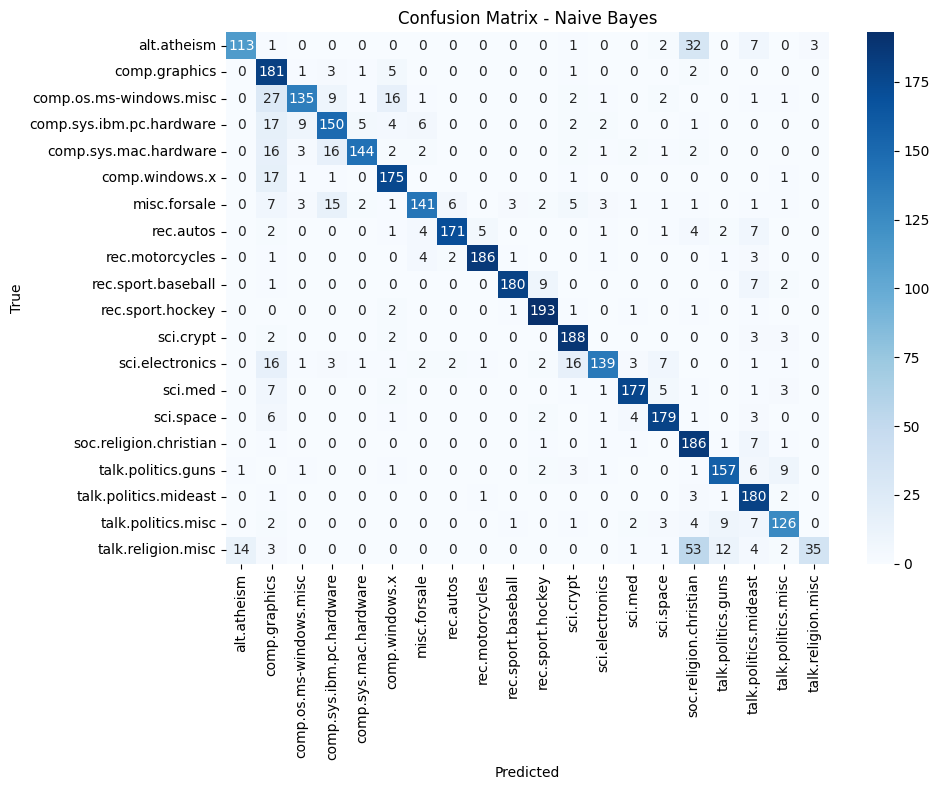

In [78]:
def plot_confusion_matrix_nb(nb_classifier, X_test_tfidf, y_test, class_names):
    # Predict
    y_pred = nb_classifier.predict(X_test_tfidf)

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - Naive Bayes')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
plot_confusion_matrix_nb(nb_classifier, X_test_tfidf, y_test, class_names=label_encoder.classes_)

From the matrix we can see that the model struggles with similar topics like religions and technology. Still these are decent results from such a simple probabilistic model.

## Real word examples

Next lets see how the model performs on real world articles.

In [49]:
new_texts = [
    # Windows and PCs
    "This means that any University desktop or laptop PCs which are still using Windows 10 will need to be upgraded to Windows 11 or replaced with more up-to-date equipment if they are unable to support Windows 11, as otherwise they will leave the University exposed to an increased cyber risk. This work is mandatory; any PCs which are still running Windows 10 will be blocked from the University network at some point in the future. Soon, colleagues             and postgraduate researchers with Windows 10 PCs will be able to arrange their own upgrade, and choose a suitable time slot for this.",
    # Rockets and space
    "This week, a busy launch manifest saw SpaceX launch the Crew-10 and two Starlink missions from Florida and the delayed SPHEREx/PUNCH and Transporter 13 missions from California.Outside of the United States, Rocket Lab flew an Electron from New Zealand. A Chang Zhang 8 rocket launched from a new commercial pad in China which also launched two other rockets. A Russian Angara rocket launched an unknown payload from Plesetsk.",
    # Apple Mac Studio
    "Apple today announced the new Mac Studio, the most powerful Mac ever made, featuring M4 Max and the new M3 Ultra chip. The ultimate pro desktop delivers groundbreaking pro performance, extensive connectivity now with Thunderbolt 5, and new capabilities in its compact and quiet design that can live right on a desk. Mac Studio can tackle the most intense workloads with its powerful CPU, Apple’s advanced graphics architecture, higher unified memory capacity, ultrafast SSD storage, and a faster and more efficient Neural Engine. It provides a big boost in performance compared to the previous generation, and a massive leap for users coming from older Macs.",
    # The Pope is dead
    "The seat at the Vatican had been vacant for two days when a group of grey-clad nuns stood on St Peter's Square and started to sing. Softly at first then louder, as if to encourage those who joined in timidly, the nuns broke into Ave Maria. Every so often they shuffled a few inches forward, following the queue for Pope Francis's lying in state. And all the while they sang, their faces turned to St Peter's Basilica to their left, their white veils glistening under their large sun hats. It was a fitting sight for an extraordinary week in which Rome seemed to regain its reputation as the 'capital of the world' – and St Peter's Square as the centre of the Catholic universe.",]

# Lemmatize the articles
lemmatized_new_texts = []
for text in new_texts:
    lemmatized_new_texts.append(lemmatize_text(text)) 

# Vectorize the articles
new_texts_tfidf = vectorizer.transform(lemmatized_new_texts)  # Transform using the trained vectorizer

In [50]:
predictions = nb_classifier.predict(new_texts_tfidf)
print(label_encoder.classes_[predictions])

['comp.os.ms-windows.misc' 'sci.space' 'comp.sys.mac.hardware'
 'talk.politics.mideast']


The model successfully predicted the first 3 articles but predicted the wrong topic for the article about the Popes death.

Next we moved on to a simple neural network based classifier in hopes of even better results.